In [1]:
import pandas as pd


df = pd.read_csv("uncleaned bike sales data.csv")

df.head(10)


,Sales_Order #,Date,Day,Month,Year,Customer_Age,Age_Group,Customer_Gender,Country,State,Product_Category,Sub_Category,Product_Description,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue
0,261695,12/1/2021,1.0,December,2021,39,Adults (35-64),F,United States,California,Bikes,Mountain Bikes,"Mountain-200 Black, 46",4.0,"$1,252.00","$2,295.00","$4,172.00","$5,008.00","$9,180.00"
1,261695,12/1/2021,1.0,December,2021,44,Adults (35-64),M,United Kingdom,England,Bikes,Mountain Bikes,"Mountain-200 Silver, 42",1.0,"$1,266.00","$2,320.00","$1,054.00","$1,266.00","$2,320.00"
2,261697,12/2/2021,2.0,December,2021,37,Adults (35-64),M,United States,California,Bikes,Mountain Bikes,"Mountain-400-W Silver, 46",2.0,$420.00,$769.00,$698.00,$840.00,"$1,538.00"
3,261698,12/2/2021,2.0,December,2021,31,Young Adults (25-34),F,Australia,New South Wales,Bikes,Mountain Bikes,"Mountain-400-W Silver, 42",1.0,$420.00,$769.00,$349.00,$420.00,$769.00
4,261699,12/3/2021,3.0,December,2021,37,Adults (35-64),F,United States,California,Bikes,Mountain Bikes,"Mountain-200 Black, 46",2.0,$0.00,"$2,295.00","$2,086.00",$0.00,"$4,590.00"
5,261700,12/3/2021,3.0,December,2021,24,Youth (<25),F,United Kingdom,England,Bikes,Mountain Bikes,"Mountain-200 Black, 38",1.0,"$1,252.00","$2,295.00","$1,043.00","$1,252.00","$2,295.00"
6,261701,12/3/2021,3.0,December,2021,37,Adults (35-64),M,United States,Washington,Bikes,Mountain Bikes,"Mountain-200 Black, 46",1.0,"$1,252.00","$2,295.00","$1,043.00","$1,252.00","$2,295.00"
7,261701,12/3/2021,3.0,December,2021,37,Adults (35-64),M,United States,Washington,Bikes,Mountain Bikes,"Mountain-200 Black, 46",1.0,"$1,252.00","$2,295.00","$1,043.00","$1,252.00","$2,295.00"
8,261702,12/4/2021,4.0,December,2021,31,Young Adults (25-34),F,Australia,New South Wales,Bikes,Mountain Bikes,"Mountain-400-W Silver, 42",4.0,$420.00,$0.00,"$1,396.00","$1,680.00",$0.00
9,261703,12/5/2021,5.0,December,2021,39,Adults (35-64),F,United States,California,Bikes,Mountain Bikes,"Mountain-200 Black, 46",4.0,"$1,252.00","$2,295.00","$4,172.00","$5,008.00","$9,180.00"


In [2]:
df.columns

Index(['Sales_Order #', 'Date', 'Day', 'Month', 'Year', 'Customer_Age',
       'Age_Group', 'Customer_Gender', 'Country', 'State', 'Product_Category',
       'Sub_Category', 'Product_Description', 'Order_Quantity', ' Unit_Cost ',
       ' Unit_Price ', ' Profit ', ' Cost ', 'Revenue'],
      dtype='object')

In [3]:
#starting data cleaning

print(df.isnull().sum())

Sales_Order #          0
Date                   0
Day                    1
Month                  0
Year                   0
Customer_Age           0
Age_Group              1
Customer_Gender        0
Country                0
State                  0
Product_Category       0
Sub_Category           0
Product_Description    1
Order_Quantity         1
 Unit_Cost             0
 Unit_Price            0
 Profit                0
 Cost                  0
Revenue                0
dtype: int64


In [4]:
df[df.isnull().any(axis=1)]

,Sales_Order #,Date,Day,Month,Year,Customer_Age,Age_Group,Customer_Gender,Country,State,Product_Category,Sub_Category,Product_Description,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue
10,261704,12/5/2021,NaN,December,2021,42,Adults (35-64),M,Germany,Nordrhein-Westfalen,Bikes,Mountain Bikes,"Mountain-200 Black, 38",4.0,"$1,252.00","$2,295.00","$4,172.00","$5,008.00","$9,180.00"
15,261709,12/6/2021,6.0,December,2021,36,NaN,M,Australia,New South Wales,Bikes,Mountain Bikes,"Mountain-200 Black, 42",1.0,"$1,252.00","$2,295.00","$1,043.00","$1,252.00","$2,295.00"
21,261715,12/8/2021,8.0,December,2021,39,Adults (35-64),F,United States,Oregon,Bikes,Mountain Bikes,NaN,2.0,"$1,252.00","$2,295.00","$2,086.00","$2,504.00","$4,590.00"
22,261716,12/8/2021,8.0,December,2021,35,Adults (35-64),F,United States,California,Bikes,Mountain Bikes,"Mountain-500 Black, 42",NaN,$295.00,$540.00,$245.00,$0.00,$0.00


In [5]:
df['Day'] = df['Day'].interpolate(method='linear')

In [6]:
print (df.iloc[10])

Sales_Order #                          261704
Date                                12/5/2021
Day                                       5.0
Month                                December
Year                                     2021
Customer_Age                               42
Age_Group                      Adults (35-64)
Customer_Gender                             M
Country                               Germany
State                     Nordrhein-Westfalen
Product_Category                        Bikes
Sub_Category                   Mountain Bikes
Product_Description    Mountain-200 Black, 38
Order_Quantity                            4.0
 Unit_Cost                         $1,252.00 
 Unit_Price                        $2,295.00 
 Profit                            $4,172.00 
 Cost                              $5,008.00 
Revenue                            $9,180.00 
Name: 10, dtype: object


In [7]:
def age_category(age):
    if pd.isnull(age):
        return 'Eligible (<18)'
    elif age < 18:
        return 'Youth (<18)'
    elif age < 35:
        return 'Young Adults (18-34)'
    elif age < 60:
        return 'Middle Age (35-59)'
    else:
        return 'Senior (60+)'

df['Age_Group'] = df['Age_Group'].fillna(df['Customer_Age'].apply(age_category))

In [8]:
print (df.iloc[15])

Sales_Order #                          261709
Date                                12/6/2021
Day                                       6.0
Month                                December
Year                                     2021
Customer_Age                               36
Age_Group                  Middle Age (35-59)
Customer_Gender                             M
Country                             Australia
State                         New South Wales
Product_Category                        Bikes
Sub_Category                   Mountain Bikes
Product_Description    Mountain-200 Black, 42
Order_Quantity                            1.0
 Unit_Cost                         $1,252.00 
 Unit_Price                        $2,295.00 
 Profit                            $1,043.00 
 Cost                              $1,252.00 
Revenue                            $2,295.00 
Name: 15, dtype: object


In [9]:
df['Product_Description'] = df['Product_Description'].fillna(df['Sub_Category']).fillna("Unknown")

In [10]:
print (df.iloc[21])

Sales_Order #                  261715
Date                        12/8/2021
Day                               8.0
Month                        December
Year                             2021
Customer_Age                       39
Age_Group              Adults (35-64)
Customer_Gender                     F
Country                 United States
State                          Oregon
Product_Category                Bikes
Sub_Category           Mountain Bikes
Product_Description    Mountain Bikes
Order_Quantity                    2.0
 Unit_Cost                 $1,252.00 
 Unit_Price                $2,295.00 
 Profit                    $2,086.00 
 Cost                      $2,504.00 
Revenue                    $4,590.00 
Name: 21, dtype: object


In [11]:
df['Order_Quantity'] = df['Order_Quantity'].fillna(1)
df.loc[df['Order_Quantity'] <= 0, 'Order_Quantity'] = 1

In [12]:
print (df.iloc[22])

Sales_Order #                          261716
Date                                12/8/2021
Day                                       8.0
Month                                December
Year                                     2021
Customer_Age                               35
Age_Group                      Adults (35-64)
Customer_Gender                             F
Country                         United States
State                              California
Product_Category                        Bikes
Sub_Category                   Mountain Bikes
Product_Description    Mountain-500 Black, 42
Order_Quantity                            1.0
 Unit_Cost                           $295.00 
 Unit_Price                          $540.00 
 Profit                              $245.00 
 Cost                                  $0.00 
Revenue                                $0.00 
Name: 22, dtype: object


In [13]:
df['Day'] = df['Day'].astype(int)

In [18]:
df['Month'] = df['Month'].astype('Int64')

In [19]:
print(df['Month'].dtype)

Int64


In [22]:
df['Month'] = df['Month'].fillna(df['Month'].mode()[0])

In [23]:
df['Date'] = pd.to_datetime(
    df[['Year', 'Month', 'Day']],
    errors='coerce'
)

In [24]:
print(df[['Year', 'Month', 'Day', 'Date']].head())

   Year  Month  Day       Date
0  2021     12    1 2021-12-01
1  2021     12    1 2021-12-01
2  2021     12    2 2021-12-02
3  2021     12    2 2021-12-02
4  2021     12    3 2021-12-03


In [25]:
df['Date'].isnull().sum()

np.int64(0)

In [26]:
df.set_index('Date', inplace=True)

In [27]:
print(df.index)

DatetimeIndex(['2021-12-01', '2021-12-01', '2021-12-02', '2021-12-02',
               '2021-12-03', '2021-12-03', '2021-12-03', '2021-12-03',
               '2021-12-04', '2021-12-05', '2021-12-05', '2021-12-05',
               '2021-12-05', '2021-12-06', '2021-12-06', '2021-12-06',
               '2021-12-06', '2021-12-07', '2021-12-07', '2021-12-08',
               '2021-12-08', '2021-12-08', '2021-12-08', '2021-12-09',
               '2021-12-09', '2021-12-10', '2021-12-10', '2021-12-10',
               '2021-12-10', '2021-12-10', '2021-12-10', '2021-12-11',
               '2021-12-11', '2021-12-11', '2021-12-11', '2021-12-11',
               '2021-12-12', '2021-12-12', '2021-12-12', '2021-12-12',
               '2021-12-12', '2021-12-13', '2021-12-13', '2021-12-13',
               '2021-12-13', '2021-12-14', '2021-12-14', '2021-12-14',
               '2021-12-15', '2021-12-16', '2021-12-16', '2021-12-16',
               '2021-12-17', '2021-12-17', '2021-12-17', '2021-12-18',
      

In [32]:
df.columns

Index(['Sales_Order #', 'Day', 'Month', 'Year', 'Customer_Age', 'Age_Group',
       'Customer_Gender', 'Country', 'State', 'Product_Category',
       'Sub_Category', 'Product_Description', 'Order_Quantity', ' Unit_Cost ',
       ' Unit_Price ', ' Profit ', ' Cost ', 'Revenue'],
      dtype='object')

In [33]:
df['Date'] = pd.to_datetime(df[['Year', 'Month', 'Day']])
df.set_index('Date', inplace=True)

sales = df['Revenue'].resample('D').sum()

In [35]:
sales = sales.asfreq('D')
sales = sales.ffill()

In [38]:
!pip install prophet

from prophet import Prophet

# Reset index (Date should come back as column)
df_reset = df.reset_index()

# Prepare dataframe
prophet_df = df_reset[['Date', 'Revenue']]
prophet_df.columns = ['ds', 'y']

print(prophet_df.head())

   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
    --------------------------------------- 0.3/12.1 MB ? eta -:--:--
    --------------------------------------- 0.3/12.1 MB ? eta -:--:--
   - -------------------------------------- 0.5/12.1 MB 551.4 kB/s eta 0:00:22
   - -------------------------------------- 0.5/12.1 MB 551.4 kB/s eta 0:00:22
   - -------------------------------------- 0.5/12.1 MB 551.4 kB/s eta 0:00:22
   - -------------------------------------- 0.5/12.1 MB 551.4 kB/s eta 0:00:22
   - -------------------------------------- 0.5/12.1 MB 551.4 kB/s eta 0:00:22
   - -------------------------------------- 0.5/12.1 MB 551.4 kB/s eta 0:00:22
   - -------------------------------------- 0.5/12.1 MB 551.4 kB/s eta 0:00:22
   - -------------------------------------- 0.5/12.1 MB 551.4 kB/s eta 0:00:22
   - -------------

In [39]:
print(prophet_df.isnull().sum())

ds    0
y     0
dtype: int64


In [41]:
df['Revenue'] = df['Revenue'].astype(str)

df['Revenue'] = df['Revenue'].str.replace('$', '', regex=False)
df['Revenue'] = df['Revenue'].str.replace(',', '', regex=False)
df['Revenue'] = df['Revenue'].str.strip()

In [42]:
df['Revenue'] = pd.to_numeric(df['Revenue'], errors='coerce')

In [43]:
print(df['Revenue'].head())
print(df['Revenue'].dtype)

Date
2021-12-01    9180.0
2021-12-01    2320.0
2021-12-02    1538.0
2021-12-02     769.0
2021-12-03    4590.0
Name: Revenue, dtype: float64
float64


In [44]:
df = df.dropna(subset=['Revenue'])

In [45]:
df_reset = df.reset_index()

prophet_df = df_reset[['Date', 'Revenue']]
prophet_df.columns = ['ds', 'y']

In [46]:
model = Prophet()
model.fit(prophet_df)

17:29:15 - cmdstanpy - INFO - Chain [1] start processing
17:29:19 - cmdstanpy - INFO - Chain [1] done processing


In [47]:
future = model.make_future_dataframe(periods=30)

In [48]:
forecast = model.predict(future)

In [49]:
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
49,2022-01-19,6708.249737,3077.794320,10447.812509
50,2022-01-20,5645.597522,1977.036767,9264.506147
51,2022-01-21,6473.211254,2823.641873,10154.226359
52,2022-01-22,6506.553314,2693.219402,10047.059991
53,2022-01-23,9052.818438,5271.613900,12839.841256


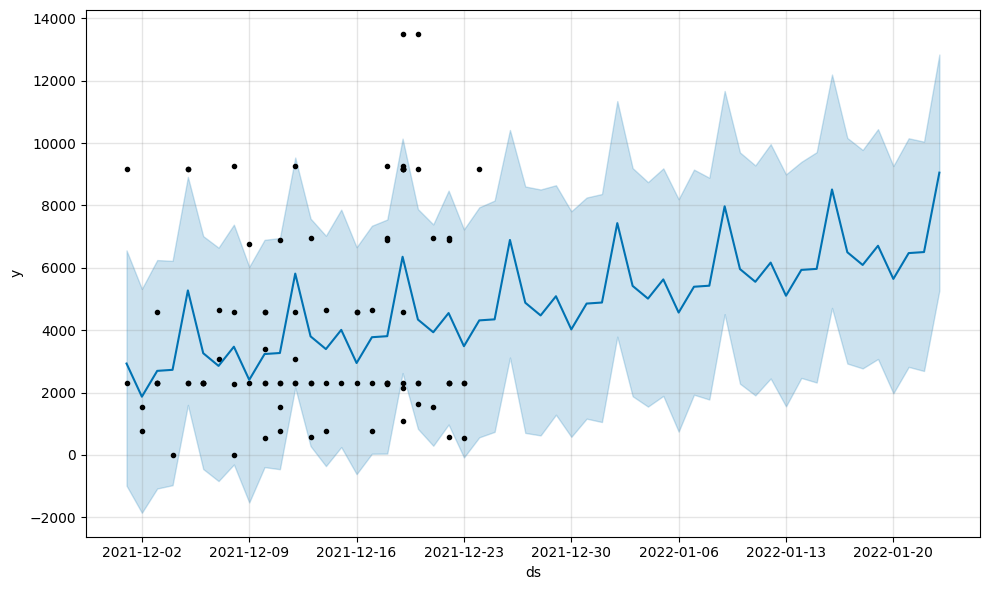

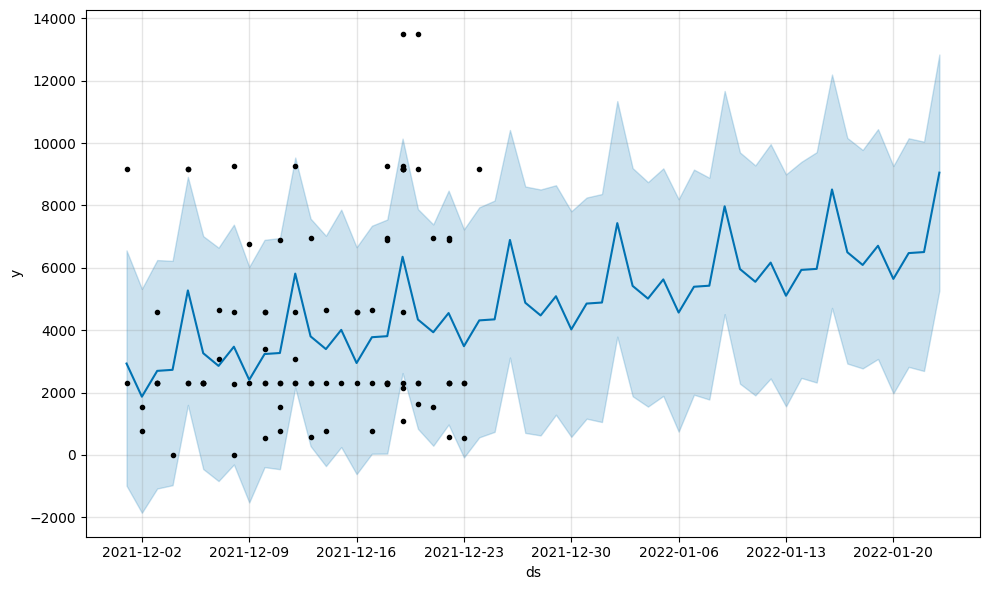

In [50]:
model.plot(forecast)

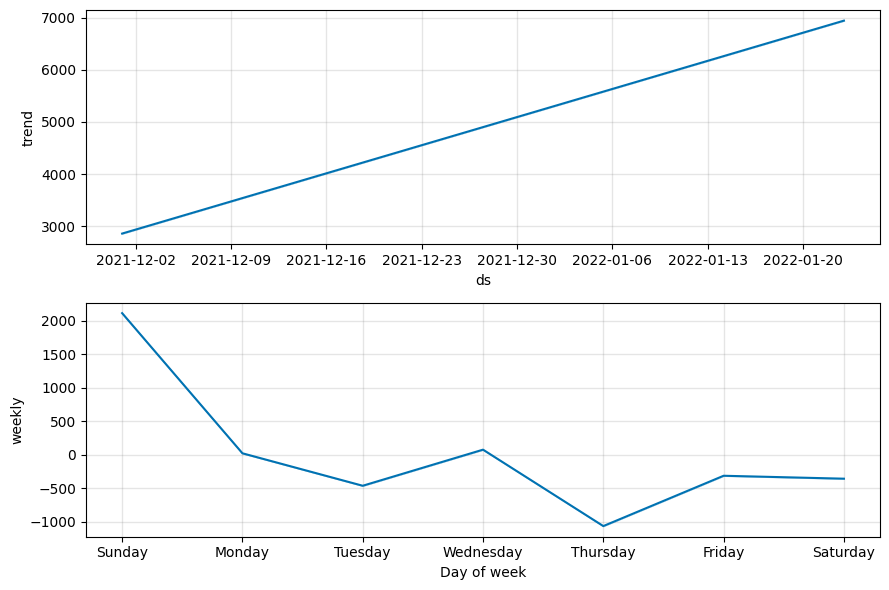

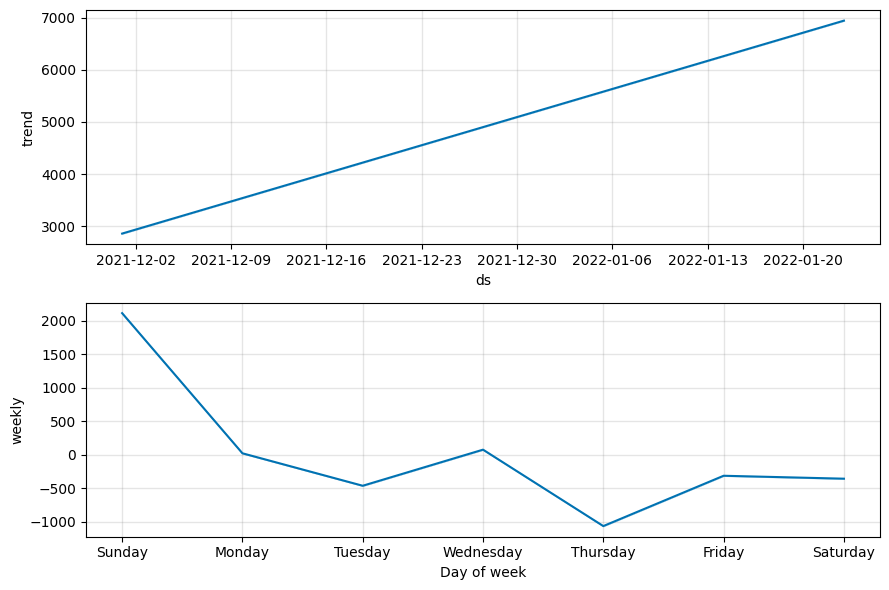

In [51]:
model.plot_components(forecast)